Data Awal:
   magnitude  depth  cdi  mmi   sig  alert
0        7.0   14.0  8.0  7.0   0.0  green
1        6.9   25.0  4.0  4.0 -33.0  green
2        7.0  579.0  3.0  3.0 -13.0  green
3        7.3   37.0  5.0  5.0  65.0  green
4        6.6  624.0  0.0  2.0 -98.0  green

Cek missing values:
magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64

Confusion Matrix:
[[57  4  0  7]
 [ 0 69  1  3]
 [ 0  3 61  0]
 [ 5  0  0 50]]

Classification Report:
              precision    recall  f1-score   support

       green       0.92      0.84      0.88        68
      orange       0.91      0.95      0.93        73
         red       0.98      0.95      0.97        64
      yellow       0.83      0.91      0.87        55

    accuracy                           0.91       260
   macro avg       0.91      0.91      0.91       260
weighted avg       0.91      0.91      0.91       260


Akurasi Model: 91.15%


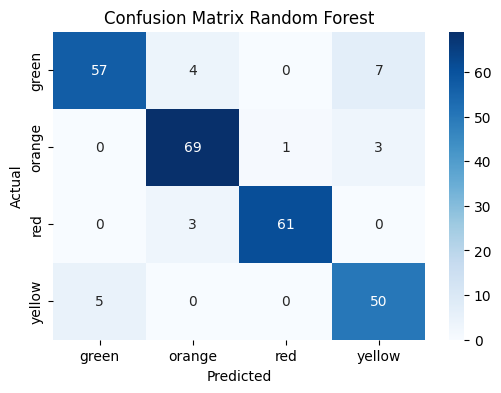

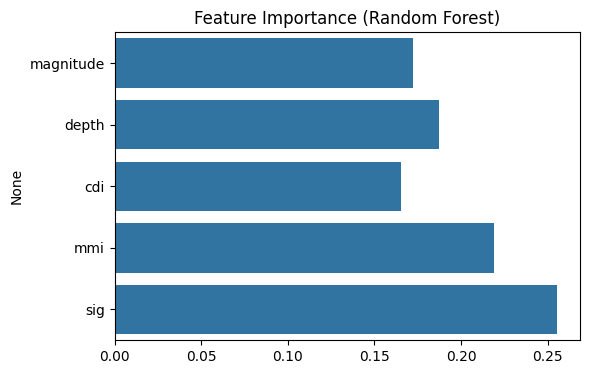

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Muat daaset
file_path = 'earthquake_alert_balanced_dataset.csv'
df = pd.read_csv(file_path, delimiter=';')

print("\n==================== DATASET ====================")
print(df.head())
print("\nJumlah baris & kolom:", df.shape)
print("Cek missing values:\n", df.isnull().sum())
print("=================================================")

# Pra proses data
le = LabelEncoder()
df['alert_encoded'] = le.fit_transform(df['alert'])

features = ['magnitude', 'depth', 'cdi', 'mmi', 'sig']
X = df[features]
y = df['alert_encoded']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\nJumlah data latih:", X_train.shape[0])
print("Jumlah data uji   :", X_test.shape[0])
print("=================================================\n")

# Artificial Neural Network (ANN)
print(" MODEL 1: ARTIFICIAL NEURAL NETWORK (ANN) ")

ann_model = MLPClassifier(
    hidden_layer_sizes=(100, 50, 20),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    verbose=False
)

ann_model.fit(X_train, y_train)
y_pred_ann = ann_model.predict(X_test)

acc_ann = accuracy_score(y_test, y_pred_ann)
print(f"\nAkurasi Model ANN: {acc_ann*100:.2f}%")
print("\nLaporan Klasifikasi ANN:")
print(classification_report(y_test, y_pred_ann, target_names=le.classes_))

cm_ann = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - ANN (Akurasi: {acc_ann*100:.2f}%)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Random Forest
print("\n=== MODEL 2: RANDOM FOREST CLASSIFIER ===")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    criterion='gini'
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAkurasi Model Random Forest: {acc_rf*100:.2f}%")
print("\nLaporan Klasifikasi Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - Random Forest (Akurasi: {acc_rf*100:.2f}%)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Visualisasi pentingnya fitur
importances = rf_model.feature_importances_
plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features, palette='crest')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Kepentingan Fitur")
plt.ylabel("Fitur")
plt.show()


# Support Vector Machine (SVM)
print("\n=== MODEL 3: SUPPORT VECTOR MACHINE (SVM) ===")

svm_model = SVC(kernel='rbf', C=2, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nAkurasi Model SVM: {acc_svm*100:.2f}%")
print("\nLaporan Klasifikasi SVM:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - SVM (Akurasi: {acc_svm*100:.2f}%)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# prediksi baru
new_data = pd.DataFrame([[6.8, 20.0, 8.0, 7.0, -101.0]], columns=features)
new_data_scaled = scaler.transform(new_data)
pred_label = le.inverse_transform(svm_model.predict(new_data_scaled))
print(f"\nContoh Prediksi Baru (SVM): {pred_label[0]}")
print("=================================================\n")

# Perbandingan Hasil Akhir
print("=== PERBANDINGAN AKURASI MODEL ===")
print(f"ANN (Artificial Neural Network): {acc_ann*100:.2f}%")
print(f"RF  (Random Forest)             : {acc_rf*100:.2f}%")
print(f"SVM (Support Vector Machine)    : {acc_svm*100:.2f}%")

# Grafik perbandingan akurasi
plt.figure(figsize=(6,4))
models = ['ANN', 'Random Forest', 'SVM']
accuracies = [acc_ann, acc_rf, acc_svm]
sns.barplot(x=models, y=accuracies, palette=['purple','green','blue'])
plt.title("Perbandingan Akurasi Tiga Model ML")
plt.ylabel("Akurasi")
plt.ylim(0,1)
plt.show()

print("\n Program selesai dijalankan.")
